# Quantum Decomposition of Financial Markets: An Investigation into the Basis Frequencies that Dominate the FTSE 100 Fluctuations
In Quantum Physics, any physical state in the Infinite Square Well can be represented as a superposition of energy eigenstates. This project investigates whether a similar decomposition can be applied to FTSE 100 returns, identifying the leading frequencies behind market fluctuations and evaluating their stability through time.

## Physics Background: The Infinitely Deep Well
The Infinite Square Well is a quantum system in which a particle is confined to a finite region of space bounded by infinitely high potential. Since the particle cannot ever escape the well (due to the infinite potential barriers), only sinusoidal solutions are permitted, resulting in a quantised set of energy eigenstates which form a basis for all possible quantum states.
The key takeaway is that any quantum state can be decomposed into linear combinations of oscillatory basis states of discrete frequencies.

The energy eigenstates of the Infinite Square Well are sinusoidal functions:

$\psi_n(x) = \sin\left(\frac{n\pi x}{L}\right), \qquad n = 1,2,3,\ldots$

where $L$ is the width of the well.

Any quantum state may therefore be represented as:

$\Psi(x,t) = \sum_{n=1}^{\infty} c_n \psi_n(x) e^{-iE_n t / \hbar}$

where $c_n$ describes the contribution of each basis state and the complex exponential term governs how the state evolves through time.

## Drawing the Analogy between Quantum Mechanics and Financial Markets
A similar mathematical decomposition can be applied beyond quantum mechanics. Any sufficiently well-behaved signal may be represented as a weighted sum of sinusoidal basis functions of different frequencies. This also closely resembles a Fourier Decomposition.

In this project, we investigate whether fluctuations in the FTSE 100 can be analysed in this quantum-mechanical lens. By identifying which frequencies dominate, we aim to understand whether sinusoidal patterns exist in market behaviour and if these structures remain stable through time.

We begin by decomposing the FTSE 100 data into a sinusoidal basis:

$M(t) = \sum_{n=1}^{N} A_n \sin(\omega_n t + \phi_n)$,

where $A_n$ is the amplitude of each basis state, $\omega_n$ is its angular frequency and $\phi_n$ is a phase offset.

# The Code:

# 1: Data Cleaning and Calculating Returns

In [1]:
# Loading in the data
import pandas as pd

ftse_df = pd.read_csv('01_FTSE100_data.csv')

ftse_df

,Date,Price,Open,High,Low,Vol.,Change %
0,09/10/2026,"10,599.66","10,659.85","10,688.85","10,593.86",254.14M,-0.66%
1,09/09/2026,"10,670.06","10,811.44","10,811.60","10,651.71",734.81M,-1.31%
2,09/08/2026,"10,811.66","10,822.26","10,850.73","10,778.06",549.77M,-0.10%
3,09/07/2026,"10,822.13","10,830.97","10,868.27","10,794.17",421.73M,-0.08%
4,09/04/2026,"10,831.09","10,831.45","10,843.12","10,791.43",675.32M,0.00%
...,...,...,...,...,...,...,...
2521,09/16/2016,"6,710.28","6,730.30","6,746.29","6,692.73",1.39B,-0.30%
2522,09/15/2016,"6,730.30","6,673.31","6,736.84","6,654.82",770.12M,0.85%
2523,09/14/2016,"6,673.31","6,665.63","6,720.29","6,665.63",695.11M,0.12%
2524,09/13/2016,"6,665.63","6,700.90","6,724.74","6,665.63",864.67M,-0.53%


In [2]:
# Checking for nulls/missing data
print(f"Total NaN count: {ftse_df.isnull().sum().sum()}")

Total NaN count: 0


In [3]:
# Cleaning date formatting

# Assigning another column 'TradingDay' to the data
ftse_df['TradingDay'] = range(len(ftse_df))[::-1]

# Now I can reverse the order to make it chronological
ftse_df = ftse_df.sort_values('TradingDay')

ftse_df

,Date,Price,Open,High,Low,Vol.,Change %,TradingDay
2525,09/12/2016,"6,700.90","6,776.95","6,776.95","6,654.48",887.97M,-1.12%,0
2524,09/13/2016,"6,665.63","6,700.90","6,724.74","6,665.63",864.67M,-0.53%,1
2523,09/14/2016,"6,673.31","6,665.63","6,720.29","6,665.63",695.11M,0.12%,2
2522,09/15/2016,"6,730.30","6,673.31","6,736.84","6,654.82",770.12M,0.85%,3
2521,09/16/2016,"6,710.28","6,730.30","6,746.29","6,692.73",1.39B,-0.30%,4
...,...,...,...,...,...,...,...,...
4,09/04/2026,"10,831.09","10,831.45","10,843.12","10,791.43",675.32M,0.00%,2521
3,09/07/2026,"10,822.13","10,830.97","10,868.27","10,794.17",421.73M,-0.08%,2522
2,09/08/2026,"10,811.66","10,822.26","10,850.73","10,778.06",549.77M,-0.10%,2523
1,09/09/2026,"10,670.06","10,811.44","10,811.60","10,651.71",734.81M,-1.31%,2524


In [4]:
# We only need to retain the 'TradingDay' and 'Price' columns
ftse_df = ftse_df.drop(['Date', 'Open', 'High', 'Low', 'Vol.', 'Change %'], axis=1)

ftse_df

,Price,TradingDay
2525,"6,700.90",0
2524,"6,665.63",1
2523,"6,673.31",2
2522,"6,730.30",3
2521,"6,710.28",4
...,...,...
4,"10,831.09",2521
3,"10,822.13",2522
2,"10,811.66",2523
1,"10,670.06",2524


In [5]:
# Now calculating log returns - to negate the effect of the increase over time

# First, we need to remove the commas in the data points
ftse_df["Price"] = ftse_df["Price"].str.replace(",", "", regex=False)

# Then, make them into floats
ftse_df["Price"] = ftse_df["Price"].astype(float)

ftse_df

,Price,TradingDay
2525,6700.90,0
2524,6665.63,1
2523,6673.31,2
2522,6730.30,3
2521,6710.28,4
...,...,...
4,10831.09,2521
3,10822.13,2522
2,10811.66,2523
1,10670.06,2524


In [6]:
# Calculating log returns (log(P_n/P_n-1))
import numpy as np

ftse_df['Price'] = ftse_df['Price'].astype(float)
ftse_df['Log Return'] = np.log(ftse_df['Price'] / ftse_df['Price'].shift(1))

ftse_df

,Price,TradingDay,Log Return
2525,6700.90,0,NaN
2524,6665.63,1,-0.005277
2523,6673.31,2,0.001152
2522,6730.30,3,0.008504
2521,6710.28,4,-0.002979
...,...,...,...
4,10831.09,2521,-0.000040
3,10822.13,2522,-0.000828
2,10811.66,2523,-0.000968
1,10670.06,2524,-0.013183


In [7]:
# Centring the data to have a mean of zero (so the oscillations are around 0)
ftse_df['De-meaned Log Return'] = ftse_df['Log Return'] - ftse_df['Log Return'].mean()

# Need to drop the first trading day, since P_-1 is not defined
ftse_df = ftse_df.dropna(axis=0, how='any')

ftse_df

,Price,TradingDay,Log Return,De-meaned Log Return
2524,6665.63,1,-0.005277,-0.005459
2523,6673.31,2,0.001152,0.000970
2522,6730.30,3,0.008504,0.008322
2521,6710.28,4,-0.002979,-0.003161
2520,6813.55,5,0.015273,0.015091
...,...,...,...,...
4,10831.09,2521,-0.000040,-0.000221
3,10822.13,2522,-0.000828,-0.001009
2,10811.66,2523,-0.000968,-0.001150
1,10670.06,2524,-0.013183,-0.013365


# 2: Initial Plot

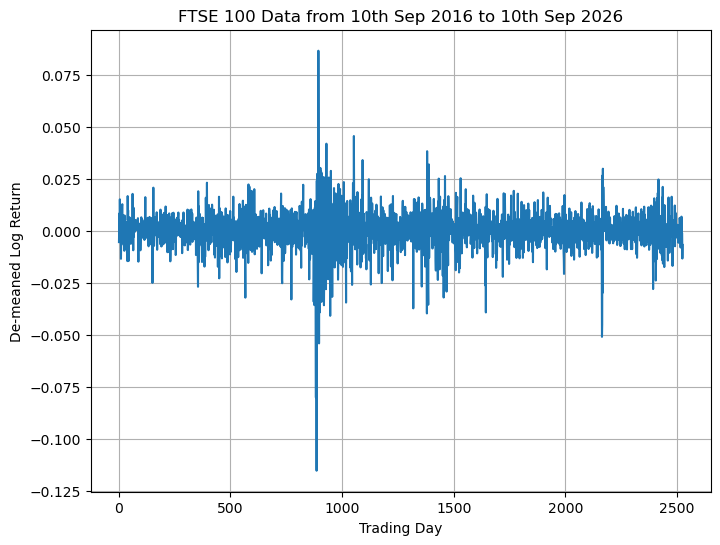

In [8]:
# Plotting full dataset
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (8,6))
ax.plot(ftse_df['TradingDay'], ftse_df['De-meaned Log Return'])
ax.grid(True)
ax.set_xlabel('Trading Day')
ax.set_ylabel('De-meaned Log Return')
ax.set_title('FTSE 100 Data from 10th Sep 2016 to 10th Sep 2026');

# 3: First pass with FFT - Using Fourier Transform to find the quantum decomposition on full data-set

I am creating a function called `fft_procedure`, since I will use it multiple times on subsets of the data.
This function performs a Fourier Transformation, plots the frequency of the results vs. their power and returns the top ten contributing frequencies.

### Power analogy

The objective of this project is to identify which frequency components contribute the most to FTSE fluctuations. Whilst the Fourier Transform decomposes a signal into its constituent frequencies, the raw Fourier coefficients are complex-valued and are therefore difficult to interpret directly.

Instead, the **power spectrum** is considered, which is defined as the square of the magnitude of each Fourier coefficient:

$ P(\omega) = |F(\omega)|^2. $

The power spectrum quantifies the contribution of each frequency to the overall variance of the signal. Frequencies with large power correspond to basis states that have a particularly strong influence on the market's behaviour, whilst frequencies with low power contribute comparatively little.

This remains analagous with the quantum-mechanical lens introduced earlier. Like the coefficients of a quantum wavefunction determine the contribution of each eigenstate to the overall state of the system, the Fourier coefficients determine the contribution of each frequency component to the overall market signal. Using a power spectrum plot, we can identify which frequencies dominate in the Fourier decomposition.

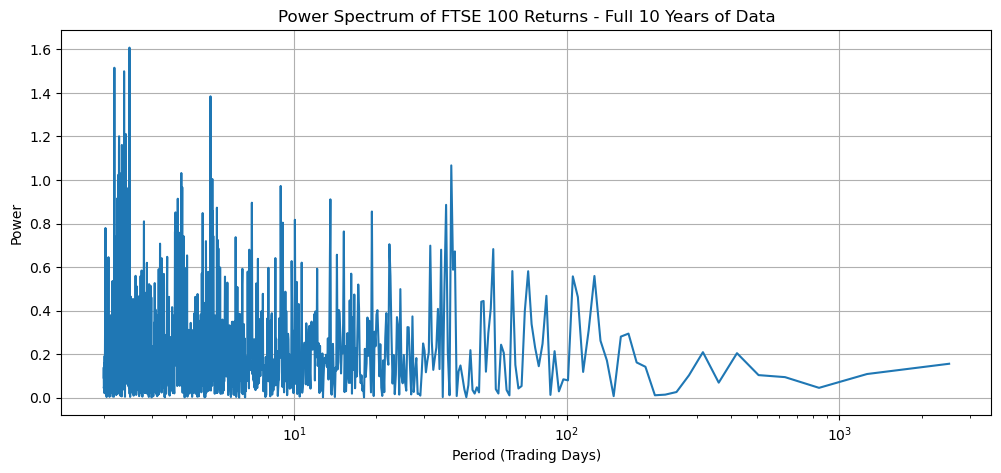

Top 10 Frequencies:
      Frequency  Period_Days     Power
1014   0.401980     2.487685  1.608259
1152   0.456634     2.189939  1.515702
1061   0.420594     2.377589  1.499416
511    0.202772     4.931641  1.384374
1045   0.414257     2.413958  1.210585
1107   0.438812     2.278881  1.200863
1081   0.428515     2.333641  1.160989
1108   0.439208     2.276826  1.131264
66     0.026535    37.686567  1.067041
1065   0.422178     2.368668  1.038608


In [31]:
def fft_procedure(returns, graph_title):
    N = len(returns) # No. of data points
    dt = 1 # Time intervals 1 - due to 'TradingDay' changes we made
    
    # Performing Fourier Transform
    fft_values = np.fft.fft(returns)
    frequencies = np.fft.fftfreq(N, d=dt)
    
    # Keeping only positive frequencies
    positive = frequencies > 0
    
    frequencies = frequencies[positive]
    fft_values = fft_values[positive]
    
    # Continuing with the Physics analogy, we're converting Amplitude to Power
    power = np.abs(fft_values) ** 2   
    
    periods = 1 / frequencies  # Calculating the period of the key frequencies
    
    # Plotting results
    plt.figure(figsize=(12,5))
    plt.plot(periods, power)
    plt.xscale("log") # Logarithmic scale due to large results
    plt.xlabel("Period (Trading Days)")
    plt.ylabel("Power")
    plt.title(graph_title)
    plt.grid(True)
    plt.show()
    
    # Top Frequencies
    results = pd.DataFrame({"Frequency": frequencies,
                            "Period_Days": periods,
                            "Power": power})
    
    top_freqs = results.sort_values("Power", ascending=False).head(10)

    return f"Top 10 Frequencies:\n{top_freqs}"

returns = ftse_df["De-meaned Log Return"]

print(fft_procedure(returns, "Power Spectrum of FTSE 100 Returns - Full 10 Years of Data"))

# 4: Refining the Analysis
The initial power spectrum obtained (using all 10 years of data) is highly noisy, with a large number of frequency components exhibiting similar magnitudes. Whilst this confirms that the FTSE 100 can be decomposed into a Fourier basis, it is hard to identify any key dominant frequencies from the spectrum.

This lack of clarity may be due to how many data points I used over so many years. This covers periods of growth, crisis, recovery and not to forget COVID-19.

To investigate whether more stable dominant frequencies exist, I will split the dataset into one-year intervals. I will then run my `fft_procedure` function  for each year, allowing the dominant frequency components to be compared across different market environments. This approach will help determine whether certain frequencies persist through time or whether the market's spectral composition evolves from year to year.

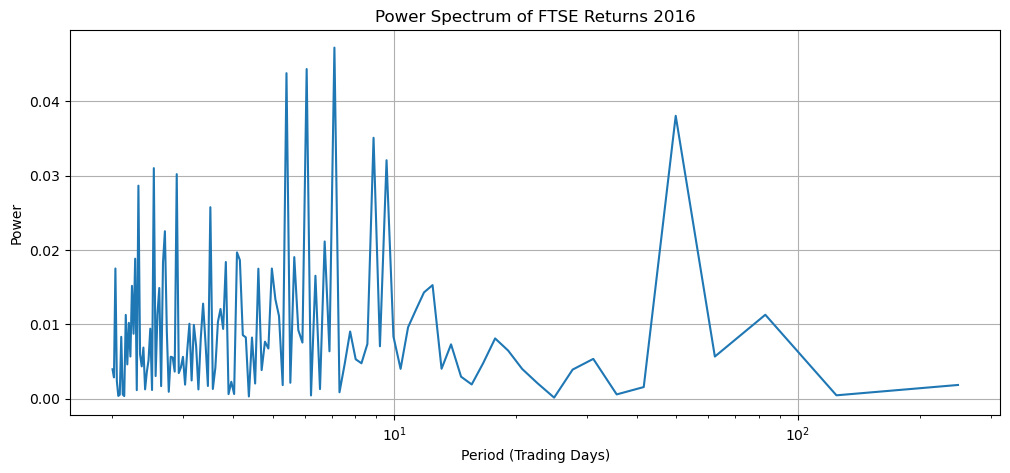

Top 10 Frequencies:
     Frequency  Period_Days     Power
34    0.140562     7.114286  0.047230
40    0.164659     6.073171  0.044347
45    0.184739     5.413043  0.043793
4     0.020080    49.800000  0.038056
27    0.112450     8.892857  0.035101
25    0.104418     9.576923  0.032082
97    0.393574     2.540816  0.031016
85    0.345382     2.895349  0.030207
106   0.429719     2.327103  0.028658
70    0.285141     3.507042  0.025760


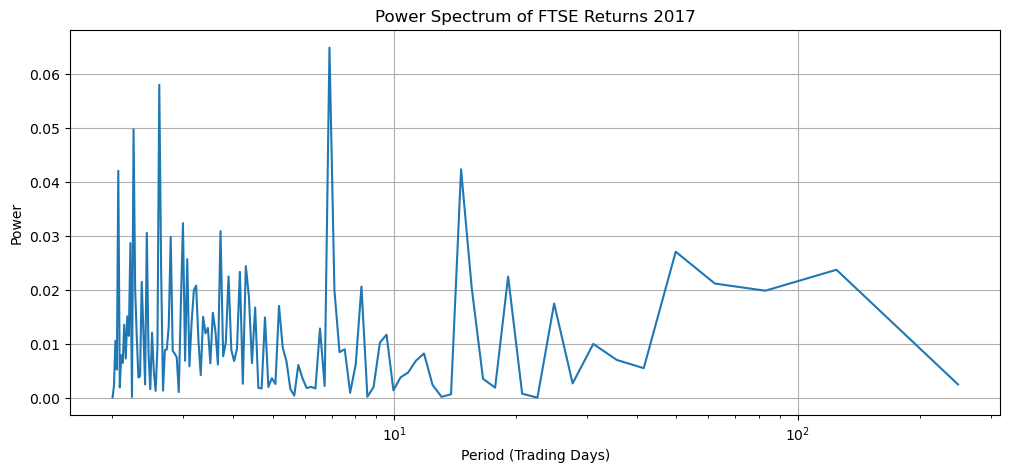

Top 10 Frequencies:
     Frequency  Period_Days     Power
35    0.144578     6.916667  0.064879
94    0.381526     2.621053  0.057972
109   0.441767     2.263636  0.049725
16    0.068273    14.647059  0.042323
119   0.481928     2.075000  0.042064
82    0.333333     3.000000  0.032366
66    0.269076     3.716418  0.030882
101   0.409639     2.441176  0.030564
88    0.357430     2.797753  0.029808
111   0.449799     2.223214  0.028673


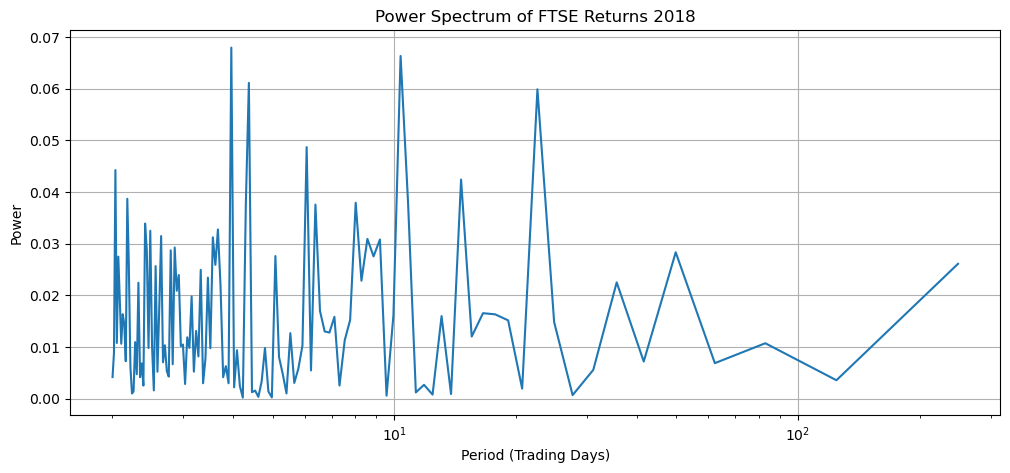

Top 10 Frequencies:
     Frequency  Period_Days     Power
62    0.253012     3.952381  0.067954
23    0.096386    10.375000  0.066342
56    0.228916     4.368421  0.061129
10    0.044177    22.636364  0.059886
40    0.164659     6.073171  0.048686
121   0.489960     2.040984  0.044244
16    0.068273    14.647059  0.042409
113   0.457831     2.184211  0.038687
22    0.092369    10.826087  0.037956
30    0.124498     8.032258  0.037924


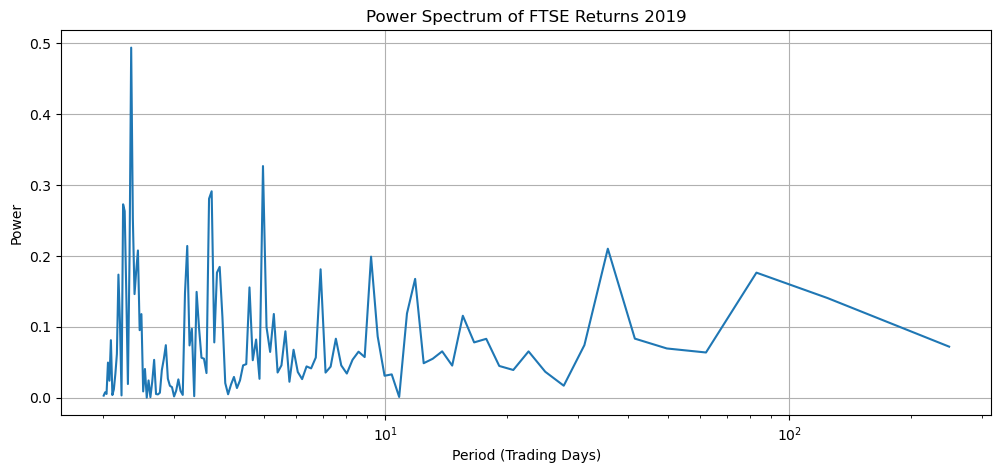

Top 10 Frequencies:
     Frequency  Period_Days     Power
105   0.425703     2.349057  0.493376
49    0.200803     4.980000  0.326455
66    0.269076     3.716418  0.290948
67    0.273092     3.661765  0.280432
110   0.445783     2.243243  0.272566
109   0.441767     2.263636  0.262963
104   0.421687     2.371429  0.252359
76    0.309237     3.233766  0.213863
6     0.028112    35.571429  0.209990
101   0.409639     2.441176  0.207526


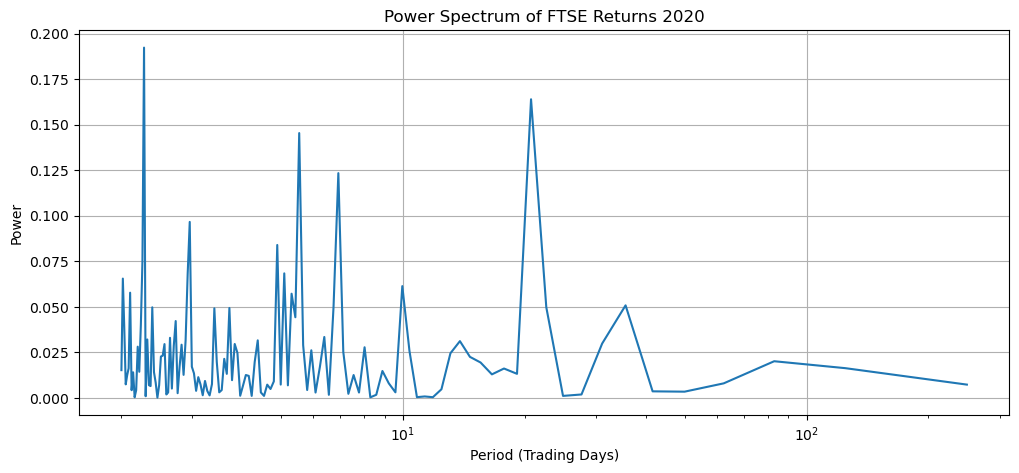

Top 10 Frequencies:
     Frequency  Period_Days     Power
108   0.437751     2.284404  0.192312
11    0.048193    20.750000  0.163955
44    0.180723     5.533333  0.145399
35    0.144578     6.916667  0.123399
83    0.337349     2.964286  0.096617
50    0.204819     4.882353  0.083953
109   0.441767     2.263636  0.074928
48    0.196787     5.081633  0.068371
84    0.341365     2.929412  0.067863
122   0.493976     2.024390  0.065501


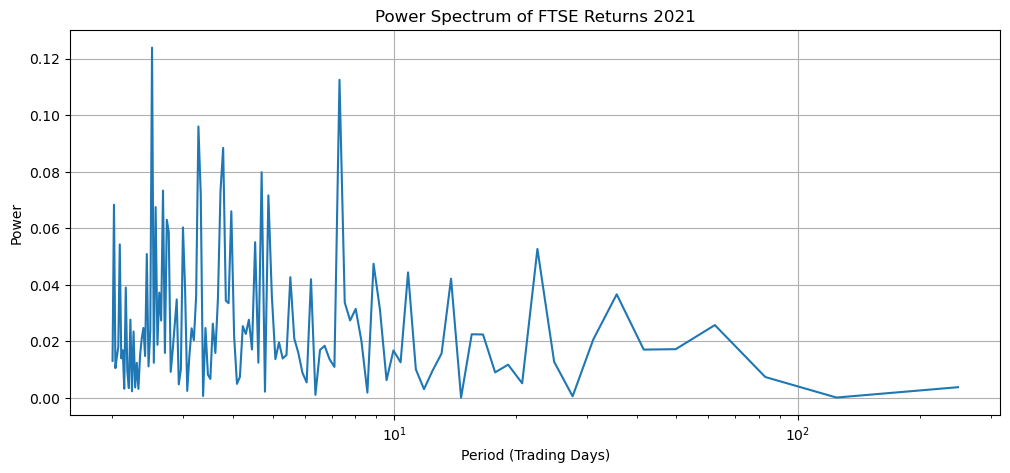

Top 10 Frequencies:
     Frequency  Period_Days     Power
98    0.397590     2.515152  0.123941
33    0.136546     7.323529  0.112547
75    0.305221     3.276316  0.096043
65    0.265060     3.772727  0.088481
52    0.212851     4.698113  0.079861
92    0.373494     2.677419  0.073350
66    0.269076     3.716418  0.073304
74    0.301205     3.320000  0.072039
50    0.204819     4.882353  0.071668
122   0.493976     2.024390  0.068372


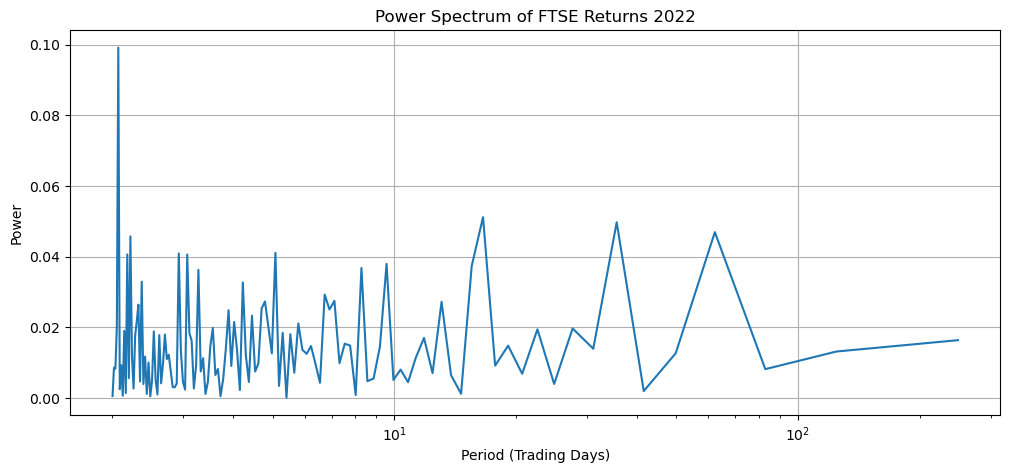

Top 10 Frequencies:
     Frequency  Period_Days     Power
119   0.481928     2.075000  0.099164
14    0.060241    16.600000  0.051176
6     0.028112    35.571429  0.049740
3     0.016064    62.250000  0.046943
111   0.449799     2.223214  0.045746
48    0.196787     5.081633  0.041087
84    0.341365     2.929412  0.040921
113   0.457831     2.184211  0.040649
80    0.325301     3.074074  0.040618
25    0.104418     9.576923  0.037962


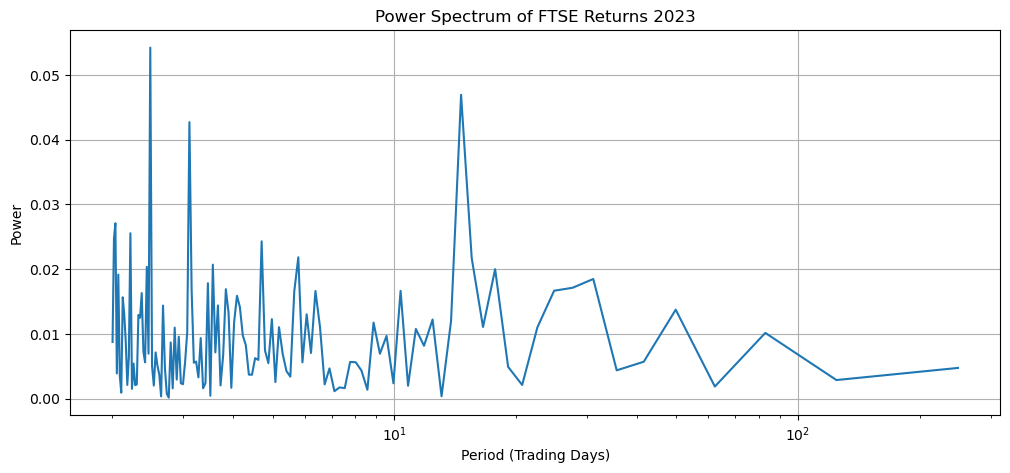

Top 10 Frequencies:
     Frequency  Period_Days     Power
99    0.401606     2.490000  0.054212
16    0.068273    14.647059  0.046928
79    0.321285     3.112500  0.042698
121   0.489960     2.040984  0.027072
111   0.449799     2.223214  0.025535
122   0.493976     2.024390  0.024727
52    0.212851     4.698113  0.024291
42    0.172691     5.790698  0.021825
15    0.064257    15.562500  0.021712
69    0.281124     3.557143  0.020685


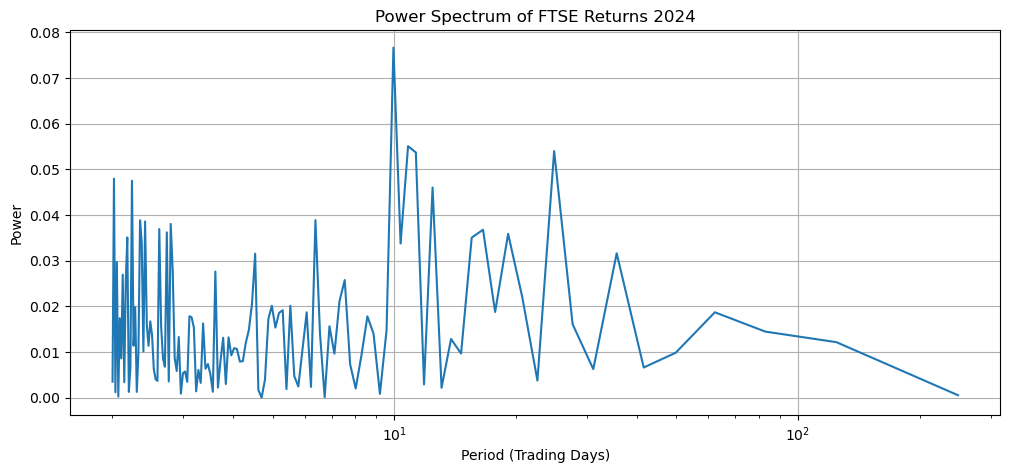

Top 10 Frequencies:
     Frequency  Period_Days     Power
24    0.100402     9.960000  0.076614
22    0.092369    10.826087  0.055049
9     0.040161    24.900000  0.053980
21    0.088353    11.318182  0.053676
122   0.493976     2.024390  0.047930
110   0.445783     2.243243  0.047479
19    0.080321    12.450000  0.045991
38    0.156627     6.384615  0.038855
105   0.425703     2.349057  0.038826
102   0.413655     2.417476  0.038571


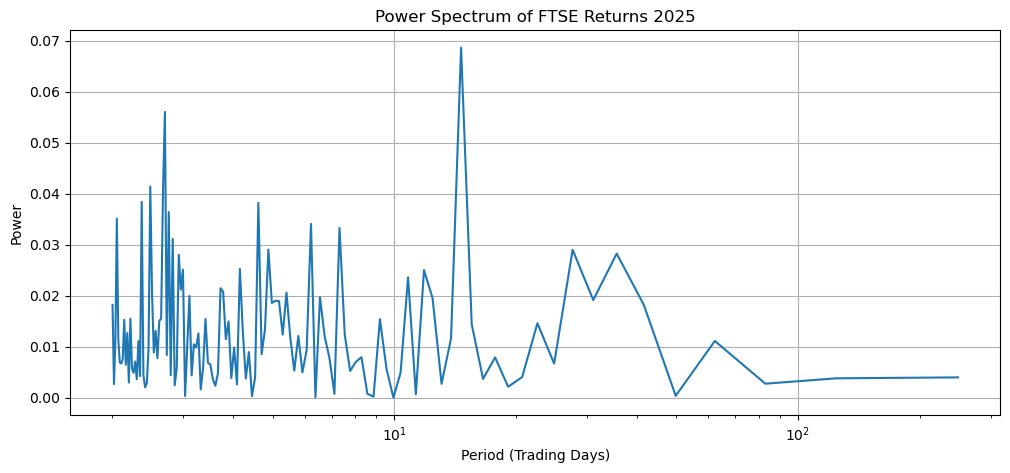

Top 10 Frequencies:
     Frequency  Period_Days     Power
16    0.068273    14.647059  0.068605
91    0.369478     2.706522  0.056010
99    0.401606     2.490000  0.041370
92    0.373494     2.677419  0.040413
104   0.421687     2.371429  0.038355
53    0.216867     4.611111  0.038188
89    0.361446     2.766667  0.036375
120   0.485944     2.057851  0.035098
39    0.160643     6.225000  0.034041
33    0.136546     7.323529  0.033260


In [32]:
# Running the algorithm on each year of data separately

intervals =  np.arange(0,len(returns),249)

for i in range(len(intervals)-1):
    print(fft_procedure(returns[intervals[i]:intervals[i+1]], f"Power Spectrum of FTSE Returns {2016+i}"))

# 5: Discussion of Results

The initial Fourier decomposition of the full 10-year dataset produced a noisy power spectrum, making it difficult to identify any dominant frequencies. To determine whether a pattern could be spotted, the dataset was partitioned into annual intervals and analysed individually.

Over all of the years considered, the resulting power spectra showed similar structures. Rather than one dominant frequency appearing, the FTSE returns were consistently distributed across a range of basis frequencies, suggesting that market fluctuations cannot be well-described by only a few sinusoidal components.

However, several frequency bands were seen again and again:

- High-power contributions were seen with periods between **2 and 7 trading days**.
- Another cluster of peaks appeared between **7 and 15 trading days**.
- Longer-period high-power contributions (>20 trading days) occasionally were seen but were generally less consistent between years.

These frequencies were not consistent in amplitude or ranking. Frequencies which appeared prominently in one year often weakened or disappeared entirely in another, indicating that the basis decomposition of the market is constantly evolving.

An interesting result was observed in **2020**, where several peaks were of greater power than any other year. The strongest component corresponded to a period of approximately **2.3 trading days**, while additional significant peaks appeared around **5.5 days** and **20.8 days**. This is likely associated with COVID-19 causing an especially volatile market, suggesting that changes in market regime can have a pronounced effect on the distribution of spectral power.

Across multiple years, periods in the range of **6 to 8 trading days** appeared repeatedly amongst the strongest components. Similarly, frequencies corresponding to periods of approximately **14 to 15 trading days** appeared in both 2017 and 2025, potentially indicating the presence of medium-term cyclical behaviour. However, the variability observed across other years suggests that these frequencies should not be interpreted as fixed market cycles without further statistical testing.

From the perspective of the original quantum analogy, the results suggest that the FTSE 100 can indeed be represented as a superposition of sinusoidal basis states. However, unlike a simple quantum system whose behaviour may be dominated by a small number of eigenstates, the market appears to occupy a far more complex superposition, with the relative contribution of individual basis states changing significantly over time.

Overall, the analysis provides evidence that Fourier decomposition is capable of revealing structure within market returns, but does not support the existence of a small set of persistent frequencies governing market behaviour. Instead, the FTSE 100 appears to behave as a stochastic and dynamic system whose basis decomposition depends strongly on changes in market conditions.